In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/MIRCV/CV/

Mounted at /content/drive
/content/drive/MyDrive/MIRCV/CV


In [2]:
!pip install opencv-python

# Medical Image Classification using Transfer Learning
## 1. Setup and Reproducibility
In this section, we import the necessary libraries and set a manual seed to ensure that our experiments are reproducible. This is a fundamental step in scientific research to ensure that results can be verified.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import torchvision
from PIL import Image
from torch.utils.data import Dataset
import numpy as np
import random
import os
import time
import copy
import cv2
import kagglehub
import shutil
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import torch.nn.functional as F
import glob
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import label_binarize

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Part 1: Chest X-Ray Classification

## 2. Data Pre-processing
Medical images often come in different sizes and orientations. We apply:
1. **Resizing**: Standardizing images to 224x224 to match the input requirements of VGG16.
2. **Data Augmentation**: We use random rotations and horizontal flips to increase the diversity of our training set, which is crucial when dealing with limited medical datasets.
3. **Normalization**: We use the mean and standard deviation of ImageNet since we are using a pre-trained model.

In [ ]:
# ImageNet statistics
means = [0.485, 0.456, 0.406]
stds = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

## 3. Dataset Selection
In this project, we focus on the **ChestX-ray14** dataset (NIH), which is one of the most prominent open-source datasets in medical imaging.
The full NIH Chest X-ray dataset is too large (~42GB) for a standard Colab environment.
To ensure stability and reproducibility without exceeding disk limits, we will use the **Official Sample Subset** provided by NIH on Kaggle.
This subset contains 5,606 images, which is scientifically significant for demonstrating Transfer Learning and evaluating model performance via AUC-ROC metrics.

In [ ]:
print("Downloading ChestX-ray Dataset...")

raw_path_chestxray = kagglehub.dataset_download("nih-chest-xrays/sample")
print("Path to dataset files:", raw_path_chestxray)

base_dir = './dataset/chestxray'
os.makedirs(base_dir, exist_ok=True)

csv_source = os.path.join(raw_path_chestxray, 'sample_labels.csv')
shutil.copy(csv_source, os.path.join(base_dir, 'metadata_sample.csv'))

print("Data downloaded successfully.")

## 4. Custom Medical Dataset Class
We define the `ChestXrayDataset` class to handle the multi-label nature of our data.
The images are located in the `raw_path` directory provided by KaggleHub, while the labels are read from the CSV file we just copied.

In [ ]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

        self.all_labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
                           'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
                           'Fibrosis', 'Pleural_Thickening', 'Hernia']

        self.label_map = {label: i for i, label in enumerate(self.all_labels)}
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Prendiamo il nome dell'immagine dal CSV
        img_name = self.df.iloc[idx]['Image Index']
        # Costruiamo il percorso completo puntando alla cartella del download originale
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)


        # Multi-label Encoding: trasformiamo le stringhe in vettori numerici
        label_str = self.df.iloc[idx]['Finding Labels']
        labels = label_str.split('|')
        target = torch.zeros(len(self.all_labels), dtype=torch.float32)
        #labels = torch.zeros(len(self.all_labels))
        # for i, pathology in enumerate(self.all_labels):
        #     if pathology in label_str:
        #         labels[i] = 1.0

        # if self.transform:
        #     image = self.transform(image)
        if label_str != 'No Finding':
            for label in labels:
                if label in self.label_map:
                    idx_label = self.label_map[label]
                    target[idx_label] = 1.0

        return image, target

## 5. Splitting and Loading Data
To avoid **Data Leakage**, we split our dataset based on **Patient ID**. This ensures that images from the same patient do not appear in both training and validation sets.
To avoid path errors, we use a search function to locate the images within the Kaggle cache. Once the path is confirmed, we initialize the DataLoaders using our custom `ChestXrayDataset` class and a patient-wise split to ensure data integrity.

In [ ]:
search_pattern = os.path.join(raw_path_chestxray, "**/*.png")
found_files = glob.glob(search_pattern, recursive=True)

if not found_files:
    raise FileNotFoundError("Non ho trovato immagini .png nel percorso scaricato. Riesegui il download.")

# Il percorso della cartella immagini è quello che contiene il primo file trovato
img_folder = os.path.dirname(found_files[0])
print(f"Successo! Le immagini sono in: {img_folder}")

df = pd.read_csv('./dataset/chestxray/metadata_sample.csv')

gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=SEED)
train_idx, val_idx = next(gss.split(df, groups=df['Patient ID']))

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

train_dataset = ChestXrayDataset(train_df, img_folder, transform=train_transforms)
val_dataset = ChestXrayDataset(val_df, img_folder, transform=test_transforms)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"DataLoaders pronti. Training: {len(train_dataset)} immagini, Validazione: {len(val_dataset)}")

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)

## 6. Data Visualization
To ensure our dataset is correctly loaded and the multi-label encoding works, we visualize a few samples from the training set. We display the images along with their corresponding pathology labels.

In [ ]:
def show_batch(dataloader):
    images, labels = next(iter(dataloader))
    plt.figure(figsize=(16, 8))

    # Valori di ImageNet per tornare ai colori originali
    m = np.array([0.485, 0.456, 0.406])
    s = np.array([0.229, 0.224, 0.225])

    for i in range(4):
        ax = plt.subplot(1, 4, i + 1)
        img = images[i].numpy().transpose((1, 2, 0))
        img = s * img + m # Denormalizzazione
        img = np.clip(img, 0, 1)

        plt.imshow(img)


        detected = [train_dataset.all_labels[j] for j, val in enumerate(labels[i]) if val == 1.0]
        plt.title("\n".join(detected) if detected else "No Finding", fontsize=10)
        plt.axis('off')
    plt.show()

show_batch(train_loader)

## 7. Architecture Definition: VGG16 with Transfer Learning
According to the survey paper *"Convolutional neural networks in medical image understanding"*, training a CNN from scratch on medical data is often unfeasible due to data scarcity.
We will:
- Load a **VGG16** model pre-trained on **ImageNet**.
- **Freeze** the convolutional layers (features) to preserve the learned low-level filters (edges, textures).
- Replace the final **Classifier** to adapt the network to our specific medical task (e.g., Binary Classification: Healthy vs. Pathological).

As mentioned in the survey paper, the choice of architecture is strictly related to the medical task.
We selected **VGG16** for this project because:
1. **Proven Effectiveness**: As stated in the survey, VGG models are highly effective for classification tasks in medical imaging, particularly for chest and skin pathologies.
2. **Transfer Learning Capability**: The paper highlights that pre-trained award-winning frameworks (like VGG) overcome the problem of small medical datasets.
3. **Architecture**: Its use of 3x3 convolutional kernels allows for a deeper network while maintaining a manageable number of parameters for a university-level project.

In [ ]:
model = models.vgg16(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

# Modify the classifier
# VGG16 classifier has 25088 input features in the first linear layer
num_features = model.classifier[6].in_features

num_classes = len(train_dataset.all_labels)

# Replace the last layer (assuming 14 classes for medical diagnosis)
model.classifier[6] = nn.Linear(num_features, num_classes)

model = model.to(device)

print(f"Model modified. Final layer: {model.classifier[6]}")

In [ ]:
#################################
# LOSS AND OPTIMIZER
#################################

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.SGD(model.classifier.parameters(), lr=0.001, momentum=0.9)

In [ ]:
##################################
# TRAINING LOOP
##################################

def train_model(model, dataloaders, criterion, optimizer, num_epochs=10):
    start = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')

    history = {'Train_loss': [], 'Val_loss': [], 'Train_acc': [], 'Val_acc': []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 10)

        for phase in ['Train', 'Val']:
            if phase == 'Train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            total_elements = 0    #number of bits (batch_size * num_classes)

            progress_bar = tqdm(dataloaders[phase], desc=f"{phase} Phase", leave=False)

            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'Train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'Train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                probs = torch.sigmoid(outputs)

                preds = (probs >= 0.5).float()

                running_corrects += torch.sum(preds == labels.data)
                total_elements += labels.numel() #numel returns the total number of elements in the tensor

                progress_bar.set_postfix(loss=loss.item())

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / total_elements

            print(f"{phase} Loss: {epoch_loss:.4f} Acc (Bit-wise): {epoch_acc:.4f}")

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'Val' and epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                print("Best model updated.")
        print()

    time_elapsed = time.time() - start
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val loss: {best_loss:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


###############################
# START TRAINING
###############################

dataloaders_dict = {'Train': train_loader, 'Val': val_loader}

model, history = train_model(model, dataloaders_dict, criterion, optimizer, num_epochs=5)


In [ ]:
model_save_path = "./models/vgg16_chestxray.pkl"

torch.save(model, model_save_path)
print(f"Model saved to {model_save_path}")

history_save_path = "./models/vgg16_chestxray_history.pkl"

with open(history_save_path, 'wb') as f:
    pickle.dump(history, f)

print(f"History saved to {history_save_path}")



## 10. Model Restoration and Evaluation Setup
In this section, we restore the trained VGG16 model along with its training history.
Due to the architectural complexity of the saved model object (which includes custom classifier layers), we explicitly set `weights_only=False` in `torch.load` to ensure the full and correct reconstruction of the network structure.

We also define the `evaluate_model` helper function. This function iterates over the validation set to compute the aggregate loss and extract the raw probability predictions (logits passed through a Sigmoid), which serve as the foundation for our subsequent metric calculations.

In [ ]:
model_save_path = "./models/vgg16_chestxray.pkl"
model = torch.load(model_save_path, map_location=device, weights_only=False)
model = model.to(device)
print("Model loaded successfully and moved to device.")

history_save_path = "./models/vgg16_chestxray_history.pkl"
with open(history_save_path, 'rb') as f:
    history = pickle.load(f)
print("Training history loaded successfully.")

def evaluate_model(model, iterator, criterion, device):
    model.eval()
    all_labels = []
    all_preds = []
    epoch_loss = 0

    with torch.no_grad():
        for batch in iterator:
            images = batch[0].to(device)
            labels = batch[1].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            epoch_loss += loss.item()
            preds = torch.sigmoid(outputs)
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)
    return epoch_loss / len(iterator), all_labels, all_preds

test_loss, labels_np, preds_np = evaluate_model(model, val_loader, criterion, device)


## 11. Quantitative Analysis: Comprehensive Medical Metrics
To provide a rigorous evaluation aligned with the standards of the reference survey paper, we expand our analysis beyond simple accuracy. Accuracy can be misleading in unbalanced medical datasets. Therefore, for each of the 14 pathologies, we compute:

- **AUC-ROC**: Measures the discriminative power of the model independent of a specific threshold.
- **Sensitivity (Recall)**: Critical in medicine to ensure that positive cases are not missed (minimizing False Negatives).
- **Specificity**: Evaluates the model's ability to correctly identify healthy tissue (minimizing False Positives).

### Threshold Calibration
Standard classification uses a threshold of 0.5. However, due to the high class imbalance and the critical nature of medical diagnosis, **we adjusted the decision threshold to 0.25**.
* **Rationale**: Lowering the threshold prioritizes **Sensitivity** over Precision. This allows the model to flag more potential pathologies, reducing the risk of missing rare diseases (False Negatives), which is the primary safety concern in Computer-Aided Diagnosis (CAD) systems.

The results are summarized in the DataFrame below.

In [ ]:
def compute_metrics(threshold, model_name):
  preds_binary = (preds_np > threshold).astype(int)

  metrics_dict = {
      "Pathology": [],
      "Samples (Positive)": [],
      "Avg Prob (Sick)": [],
      "AUC": [],
      "Accuracy": [],
      "Sensitivity": [],
      "Specificity": [],
      "Precision": [],
      "F1-Score": []
  }

  print(f"Calculating metrics for {len(train_dataset.all_labels)} pathologies...")

  for i, label_name in enumerate(train_dataset.all_labels):
      y_true = labels_np[:, i]
      y_pred = preds_binary[:, i]
      y_prob = preds_np[:, i]

      n_positives = int(np.sum(y_true))

      if n_positives == 0:
          continue

      avg_prob_sick = np.mean(y_prob[y_true == 1])

      try:
          auc = roc_auc_score(y_true, y_prob)
      except ValueError:
          auc = 0.5

      tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

      sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
      specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

      acc = accuracy_score(y_true, y_pred)
      prec = precision_score(y_true, y_pred, zero_division=0)
      f1 = f1_score(y_true, y_pred, zero_division=0)

      metrics_dict["Pathology"].append(label_name)
      metrics_dict["Samples (Positive)"].append(f"{len(y_true)} ({n_positives})")
      metrics_dict["Avg Prob (Sick)"].append(f"{avg_prob_sick:.4f}")
      metrics_dict["AUC"].append(auc)
      metrics_dict["Accuracy"].append(acc)
      metrics_dict["Sensitivity"].append(sensitivity)
      metrics_dict["Specificity"].append(specificity)
      metrics_dict["Precision"].append(prec)
      metrics_dict["F1-Score"].append(f1)

  metrics_df = pd.DataFrame(metrics_dict)
  metrics_df.set_index("Pathology", inplace=True)

  pd.options.display.float_format = '{:.4f}'.format

  print(f"\nOverall Validation Loss: {test_loss:.4f}")
  print(f"Metrics calculated with Threshold = {threshold}")
  print("\n=== Final Medical Metrics Report (only classes with positive samples) ===")
  display(metrics_df)

  print("\n=== Average Performance (Macro-Avg) ===")
  display(metrics_df.mean(numeric_only=True))

  filename = f"./results/metrics_{model_name}_threshold_{threshold}.csv"
  metrics_df.to_csv(filename)
  print(f"\nTabella salvata correttamente nel file: {filename}")

compute_metrics(threshold=0.1, model_name="vgg16")

## 12. Qualitative Analysis: Visual Inference
Finally, we perform a visual inspection of the model's predictions on a random batch of test images.
The grid below displays the input X-rays alongside:
- **Actual Labels**: The ground truth provided by radiologists.
- **Predicted Labels**: The top 2 pathologies predicted by the model, along with their confidence scores.

The titles are color-coded (**Blue** for correct detection, **Red** for error) to facilitate immediate visual error analysis. This step allows us to qualitatively verify if the model is focusing on relevant radiological features or if it struggles with specific co-occurring pathologies.

In [ ]:
def plot_test_results_grid(images, labels, preds, label_names, n_images=24, imgs_per_row=4):
    n_rows = (n_images + imgs_per_row - 1) // imgs_per_row

    plt.figure(figsize=(20, 6 * n_rows))

    m = np.array([0.485, 0.456, 0.406])
    s = np.array([0.229, 0.224, 0.225])

    for i in range(min(n_images, len(images))):
        ax = plt.subplot(n_rows, imgs_per_row, i + 1)

        # Denormalizzazione
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        img = s * img + m
        img = np.clip(img, 0, 1)
        plt.imshow(img)

        # Estrazione etichette (Ground Truth e Top 2 Predizioni)
        top_preds = np.argsort(preds[i])[-2:][::-1]
        actual = [label_names[j] for j, v in enumerate(labels[i]) if v == 1.0]

        pred_text = "\n".join([f"Pred: {label_names[p]} ({preds[i][p]:.2f})" for p in top_preds])
        actual_text = f"Actual: {', '.join(actual) if actual else 'None'}"

        color = 'blue' if any(labels[i][top_preds] > 0.5) else 'red'

        plt.title(f"{actual_text}\n{pred_text}", fontsize=10, color=color, pad=10)
        plt.axis('off')

    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    plt.show()


images_batch, labels_batch = next(iter(val_loader))

model.eval()
with torch.no_grad():
    outputs_batch = model(images_batch.to(device))
    preds_batch = torch.sigmoid(outputs_batch).cpu().numpy()

plot_test_results_grid(
    images=images_batch,
    labels=labels_batch.numpy(),
    preds=preds_batch,
    label_names=train_dataset.all_labels,
    n_images=12,
    imgs_per_row=4
)


## 13. Addressing Class Imbalance: Weighted Loss Calculation
Our preliminary analysis of the dataset distribution revealed a severe class imbalance. Rare pathologies like *Hernia* or *Pneumonia* are represented in less than 1-2% of the images.
Standard Binary Cross Entropy (BCE) loss treats all classes equally. Consequently, the model can achieve a low overall loss simply by predicting "No Finding" for these rare classes, leading to high Specificity but near-zero Sensitivity.

To counteract this, we calculate a **Positive Weight ($W_c$)** for each class $c$ using the formula:
$$W_c = \frac{\text{Number of Negatives}_c}{\text{Number of Positives}_c}$$

These weights will be passed to the `BCEWithLogitsLoss` function. This penalizes the model significantly more when it misses a positive case of a rare pathology, effectively forcing it to "pay attention" to the minority classes.

In [ ]:
df_path = './dataset/chestxray/metadata_sample.csv'
df = pd.read_csv(df_path)

all_labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
              'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
              'Fibrosis', 'Pleural_Thickening', 'Hernia']

pos_weights = []
total_samples = len(df)

print(f"{'Pathology':<20} | {'Positives':<10} | {'Calculated Weight':<10}")
print("-" * 55)

for label in all_labels:
  pos_count = df['Finding Labels'].str.contains(label).sum()
  neg_count = total_samples - pos_count

  weight = neg_count / pos_count if pos_count > 0 else 1.0
  pos_weights.append(weight)

  print(f"{label:<20} | {pos_count:<10} | {weight:.4f}")

pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)


criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

optimizer = optim.SGD(model.classifier.parameters(), lr=0.001, momentum=0.9)

dataloaders_dict = {'Train': train_loader, 'Val': val_loader}

print("\nStarting Re-Training with WEIGHTED LOSS...")
print("-" * 50)

model, history = train_model(model, dataloaders_dict, criterion_weighted, optimizer, num_epochs=5)

model_save_path = "./models/vgg16_chestxray_weighted.pkl"

torch.save(model, model_save_path)
print(f"Model saved to {model_save_path}")

history_save_path = "./models/vgg16_chestxray_weighted_history.pkl"

with open(history_save_path, 'wb') as f:
    pickle.dump(history, f)

print(f"History saved to {history_save_path}")


## 14. Final Evaluation: Impact of Weighted Loss
We repeat the comprehensive quantitative analysis on the model re-trained with **Weighted Loss**.

**Objective:**
To verify if the `pos_weight` strategy successfully "unlocked" the model's sensitivity for rare pathologies compared to the baseline. We expect to observe a **significant increase in Sensitivity (Recall)** for classes like *Hernia* and *Pneumonia*, likely accompanied by a trade-off decrease in Specificity.

In [ ]:
model_save_path = "./models/vgg16_chestxray_weighted.pkl"
model = torch.load(model_save_path, map_location=device, weights_only=False)
model = model.to(device)
print("Model loaded successfully and moved to device.")

history_save_path = "./models/vgg16_chestxray_weighted_history.pkl"
with open(history_save_path, 'rb') as f:
    history = pickle.load(f)
print("Training history loaded successfully.")

test_loss, labels_np, preds_np = evaluate_model(model, val_loader, criterion_weighted, device)

compute_metrics(threshold=0.5, model_name="vgg16_weighted")

## 15. eXplainable AI (XAI): Visualizing Decisions with Grad-CAM

While high accuracy metrics are promising, Deep Learning models are often criticized for being **"Black Boxes"**. In medical imaging, trust is paramount: a radiologist must verify **why** the model predicted a specific pathology.

To address this, we implement **Grad-CAM (Gradient-weighted Class Activation Mapping)**. Unlike simple activation maps, Grad-CAM uses the gradient information flowing into the last convolutional layer of the CNN to assign importance values to each neuron for a specific decision of interest.

### How it works
The technique can be summarized in three steps:

1.  **Gradient Computation**: We compute the gradient of the score for class $y^c$ with respect to the feature map activations $A^k$ of the last convolutional layer.
2.  **Global Average Pooling**: We calculate the neuron importance weights $\alpha_k^c$ by averaging the gradients over the width and height dimensions ($i, j$):
    $$\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A_{ij}^k}$$
3.  **Weighted Combination**: We perform a weighted combination of forward activation maps, followed by a **ReLU** function to obtain the heatmap. We apply ReLU because we are only interested in features that have a *positive* influence on the class of interest:
    $$L_{Grad-CAM}^c = ReLU\left(\sum_k \alpha_k^c A^k\right)$$

### Interpretation
* **Red/Hot Areas**: Regions that heavily influenced the model to classify the image as "Pathological".
* **Blue/Cold Areas**: Regions ignored by the model or that contributed negatively to the prediction.

This visual inspection allows us to detect **Bias** (e.g., if the model is looking at the background tags instead of the lungs) and validate the clinical relevance of the features learned.

In [13]:
def get_gradcam(model, image, label_idx, device):
    model.eval()

    target_layer = model.features[-1]

    for layer in reversed(model.features):
        if isinstance(layer, nn.Conv2d):
            target_layer = layer
            break

    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    hook_b = target_layer.register_full_backward_hook(backward_hook)
    hook_f = target_layer.register_forward_hook(forward_hook)

    image = image.unsqueeze(0).to(device)
    image.requires_grad = True
    output = model(image)

    model.zero_grad()

    score = output[:, label_idx]
    score.backward()

    hook_b.remove()
    hook_f.remove()

    grads = gradients[0].cpu().data.numpy()[0]
    fmap = activations[0].cpu().data.numpy()[0]

    weights = np.mean(grads, axis=(1, 2))

    cam = np.zeros(fmap.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmap[i]

    cam = np.maximum(cam, 0)

    cam = cv2.resize(cam, (224, 224))
    cam = cam - np.min(cam)
    cam = cam / np.max(cam) if np.max(cam) != 0 else cam
    return cam

def plot_gradcam(model, dataset, device, n_samples = 4):
    indices = [i for i in range(len(dataset)) if dataset[i][1].sum() > 0]

    plt.figure(figsize=(15, 5 * n_samples))

    for i in range(min(n_samples, len(indices))):
        idx = indices[i]
        image, label = dataset[idx]

        active_labels = [j for j, val in enumerate(label) if val == 1.0]

        img_show = image.permute(1, 2, 0).numpy()
        img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_show = np.clip(img_show, 0, 1)

        target_class_idx = active_labels[0]
        target_name = dataset.all_labels[target_class_idx]

        heatmap = get_gradcam(model, image, target_class_idx, device)

        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

        superimposed = 0.6 * img_show + 0.4 * heatmap_color

        ax = plt.subplot(n_samples, 3, i * 3 + 1)
        plt.imshow(img_show)
        plt.title(f"Original Image\nLabel: {target_name}", fontsize=12)
        plt.axis('off')

        ax = plt.subplot(n_samples, 3, i * 3 + 2)
        plt.imshow(heatmap, cmap='jet')
        plt.title(f"Grad-CAM Heatmap\nLabel: {target_name}", fontsize=12)
        plt.axis('off')

        ax = plt.subplot(n_samples, 3, i * 3 + 3)
        plt.imshow(superimposed)
        plt.title(f"Superimposed\nLabel: {target_name}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def fix_inplace_relu(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.inplace = False
    return model

model = fix_inplace_relu(model)
print("Correzione ReLU inplace applicata. Ora Grad-CAM dovrebbe funzionare.")

In [ ]:
print("Generating Grad-CAM visualizations...")
plot_gradcam(model, val_dataset, device, n_samples=4)

# Part 2: Brain Tumor Classification (MRI)

### 1. Dataset Preparation and Splitting
In this section, we extend our analysis to Magnetic Resonance Imaging (MRI) using the **Brain Tumor MRI Dataset**. This is a **Multi-Class classification problem** with four mutually exclusive classes: *Glioma*, *Meningioma*, *No Tumor*, and *Pituitary*.

**Addressing Data Leakage:**
A preliminary analysis of the dataset structure suggested a potential "patient overlap" issue (adjacent slices of the same patient split between training and testing folders). To ensure a scientifically rigorous evaluation and avoid inflated metrics, we adopt a robust strategy:
1.  **Merge:** We combine all images from the original Training and Testing folders into a single dataframe.
2.  **Stratified Split:** We perform a custom **Stratified Shuffle Split** (80% Train, 20% Validation) to randomize the distribution while preserving class proportions.

In [ ]:
print("Downloading Brain Tumor MRI Dataset...")

raw_path_brainmri = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", raw_path_brainmri)

base_dir = './dataset/brainmri'
os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(raw_path_brainmri, 'Training')
test_dir = os.path.join(raw_path_brainmri, 'Testing')

mri_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

class_names_mri = ['glioma', 'meningioma', 'notumor', 'pituitary']
data = []

for split_folder in ['Training', 'Testing']:
    for label in class_names_mri:
        folder_path = os.path.join(raw_path_brainmri, split_folder, label)
        files = glob.glob(os.path.join(folder_path, "*"))

        for f in files:
            data.append({"filepath": f, "label": label})

df_mri = pd.DataFrame(data)
print(f"Total images found: {len(df_mri)}")

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(splitter.split(df_mri, df_mri['label']))

train_df_mri = df_mri.iloc[train_idx].reset_index(drop=True)
val_df_mri = df_mri.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(train_df_mri)} | Val: {len(val_df_mri)}")

In [ ]:
class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.class_map = {name: i for i, name in enumerate(class_names_mri)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label_str = self.df.iloc[idx]['label']
        label = self.class_map[label_str]

        return image, torch.tensor(label, dtype=torch.long)

train_mri_ds = BrainTumorDataset(train_df_mri, transform=mri_transforms['Train'])
val_mri_ds = BrainTumorDataset(val_df_mri, transform=mri_transforms['Val'])

train_mri_loader = DataLoader(train_mri_ds, batch_size=32, shuffle=True, num_workers=2)
val_mri_loader = DataLoader(val_mri_ds, batch_size=32, shuffle=False, num_workers=2)

### 2. Model Adaptation: VGG16 for Multi-Class
We adapt the **VGG16** architecture, previously used for X-Ray analysis, to the MRI domain.
* **Transfer Learning:** We load weights pre-trained on ImageNet and freeze the feature extraction layers (`features`), focusing the training on the classifier.
* **Architecture Modification:** The final fully connected layer is modified to output **4 logits** (corresponding to the 4 classes).
* **Loss Function:** Unlike the multi-label Chest X-Ray task (which used BCE Loss), here we employ **CrossEntropyLoss**, which is suitable for multi-class problems where each image belongs to exactly one category.

In [ ]:
vgg_mri = models.vgg16(pretrained=True)

for param in vgg_mri.features.parameters():
    param.requires_grad = False

num_features = vgg_mri.classifier[6].in_features
vgg_mri.classifier[6] = nn.Linear(num_features, len(class_names_mri))

vgg_mri = vgg_mri.to(device)

criterion_mri = nn.CrossEntropyLoss()
optimizer_mri = optim.SGD(vgg_mri.classifier.parameters(), lr=0.001, momentum=0.9)

def train_mri_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {'Train_loss': [], 'Val_loss': [], 'Train_acc': [], 'Val_acc': []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        for phase in ['Train', 'Val']:
            if phase == 'Train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloader, desc=phase, leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'Train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'Train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

    return model, history

In [ ]:
print("\nStarting training VGG16 on Brain Tumor Dataset...")
model_mri, history_mri = train_mri_model(vgg_mri, train_mri_loader, val_mri_loader, criterion_mri, optimizer_mri, num_epochs=10)

torch.save(model_mri, "./models/vgg16_brain_mri.pkl")
print("Model saved.")

### 3. Quantitative Evaluation (Metrics)
We evaluate the model on the held-out validation set. Since this is a multi-class problem, we calculate metrics using a **One-vs-Rest** strategy for each class (e.g., *Glioma* vs. *All Others*).

In [ ]:
load_path = "./models/vgg16_brain_mri.pkl"

print(f"Loading model from {load_path}...")
vgg_mri = torch.load(load_path, map_location=device, weights_only=False)
vgg_mri = vgg_mri.to(device)
print("Model loaded successfully.")

In [ ]:
def evaluate_model_mri(model, iterator, criterion, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    epoch_loss = 0

    with torch.no_grad():
        for inputs, labels in iterator:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            epoch_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return epoch_loss / len(iterator), np.array(all_labels), np.array(all_preds), np.array(all_probs)

test_loss, labels_mri, preds_mri, probs_mri = evaluate_model_mri(vgg_mri, val_mri_loader, criterion_mri, device)

In [ ]:
def compute_metrics_mri(model_name):
    classes = class_names_mri

    metrics_dict = {
        "Class": [],
        "Samples": [],
        "Accuracy": [],
        "Sensitivity": [],
        "Specificity": [],
        "Precision": [],
        "F1-Score": [],
        "AUC": []
    }

    print(f"Calcolo metriche per {len(classes)} classi (One-vs-Rest)...")

    y_test_bin = label_binarize(labels_mri, classes=range(len(classes)))

    for i, class_name in enumerate(classes):
        y_true_binary = (labels_mri == i).astype(int)
        y_pred_binary = (preds_mri == i).astype(int)

        try:
            auc = roc_auc_score(y_true_binary, probs_mri[:, i])
        except ValueError:
            auc = 0.5

        tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
        f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
        acc = accuracy_score(y_true_binary, y_pred_binary)

        metrics_dict["Class"].append(class_name)
        metrics_dict["Samples"].append(np.sum(y_true_binary))
        metrics_dict["Accuracy"].append(acc)
        metrics_dict["Sensitivity"].append(sensitivity)
        metrics_dict["Specificity"].append(specificity)
        metrics_dict["Precision"].append(prec)
        metrics_dict["F1-Score"].append(f1)
        metrics_dict["AUC"].append(auc)

    metrics_df = pd.DataFrame(metrics_dict)
    metrics_df.set_index("Class", inplace=True)
    pd.options.display.float_format = '{:.4f}'.format

    print(f"\nOverall Validation Loss: {test_loss:.4f}")
    print("\n=== Final Brain Tumor Metrics Report ===")
    display(metrics_df)

    print("\n=== Average Performance (Macro-Avg) ===")
    display(metrics_df.mean(numeric_only=True))

    filename = f"./results/metrics_{model_name}_mri.csv"
    metrics_df.to_csv(filename)
    print(f"Salvato in: {filename}")

compute_metrics_mri(model_name="vgg16_brain")

### 4. Qualitative Analysis: Predictions Visualization
To better understand the model's behavior, we visualize a batch of validation images along with their Ground Truth labels and the model's top predicted class (with confidence score).
* **Blue Title:** Correct Prediction.
* **Red Title:** Misclassification.
This visual inspection helps in identifying subtle confusion patterns, such as distinguishing between visually similar tumor types (e.g., Glioma vs. Meningioma).

In [6]:
def plot_multiclass_results_grid(images, labels, outputs, label_names, n_images=12, imgs_per_row=4):
    n_rows = (n_images + imgs_per_row - 1) // imgs_per_row
    plt.figure(figsize=(20, 6 * n_rows))

    # Costanti per denormalizzare (ImageNet stats)
    m = np.array([0.485, 0.456, 0.406])
    s = np.array([0.229, 0.224, 0.225])

    probs = torch.softmax(outputs, dim=1)
    max_probs, preds = torch.max(probs, dim=1)

    for i in range(min(n_images, len(images))):
        ax = plt.subplot(n_rows, imgs_per_row, i + 1)

        img = images[i].cpu().numpy().transpose((1, 2, 0))
        img = s * img + m
        img = np.clip(img, 0, 1)
        plt.imshow(img)

        actual_idx = labels[i].item()
        pred_idx = preds[i].item()
        confidence = max_probs[i].item()

        actual_text = label_names[actual_idx]
        pred_text = label_names[pred_idx]

        color = 'blue' if actual_idx == pred_idx else 'red'

        title_text = f"Actual: {actual_text}\nPred: {pred_text} ({confidence:.2%})"

        plt.title(title_text, fontsize=12, color=color, fontweight='bold', pad=10)
        plt.axis('off')

    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    plt.show()

# images_batch, labels_batch = next(iter(val_mri_loader))

# images_batch = images_batch.to(device)
# vgg_mri.eval()

# with torch.no_grad():
#     outputs_batch = vgg_mri(images_batch)

# plot_multiclass_results_grid(
#     images=images_batch.cpu(),
#     labels=labels_batch.cpu(),
#     outputs=outputs_batch.cpu(),
#     label_names=class_names_mri,
#     n_images=24,
#     imgs_per_row=4
# )

### 5. Explainable AI (XAI) with Grad-CAM
Finally, we apply **Grad-CAM (Gradient-weighted Class Activation Mapping)** to validate the reliability of our model.
* **Objective:** To verify that the network is focusing on the actual tumor mass rather than irrelevant anatomical features (e.g., skull borders) or background artifacts.
* **Technical Note:** We explicitly disable the `inplace=True` operation in VGG16's ReLU layers to correctly compute gradients for the visualization.
The heatmaps below overlay the network's attention on the original MRI scans.

In [8]:
def fix_inplace_relu(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.inplace = False
    return model

# vgg_mri = fix_inplace_relu(vgg_mri)
# print("Fix ReLU inplace applied to VGG MRI.")

def plot_gradcam_multiclass(model, dataset, device, class_names, n_samples=4):
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    plt.figure(figsize=(15, 5 * n_samples))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        target_class_idx = label.item()
        target_name = class_names[target_class_idx]

        heatmap = get_gradcam(model, image, target_class_idx, device)

        img_show = image.permute(1, 2, 0).numpy()
        img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_show = np.clip(img_show, 0, 1)

        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        superimposed = 0.6 * img_show + 0.4 * heatmap_color

        ax = plt.subplot(n_samples, 3, i * 3 + 1)
        plt.imshow(img_show)
        plt.title(f"Original MRI\nClass: {target_name}", fontsize=12)
        plt.axis('off')

        ax = plt.subplot(n_samples, 3, i * 3 + 2)
        plt.imshow(heatmap, cmap='jet')
        plt.title(f"Grad-CAM Heatmap", fontsize=12)
        plt.axis('off')

        ax = plt.subplot(n_samples, 3, i * 3 + 3)
        plt.imshow(superimposed)
        plt.title(f"Superimposed Focus", fontsize=12)
        plt.axis('off')

    print("Generating XAI Brain Tumor Explanations...")
    plt.tight_layout()
    plt.show()


# plot_gradcam_multiclass(vgg_mri, val_mri_ds, device, class_names_mri, n_samples=4)

# Part 3: Skin Cancer Classification

Di seguito imposto il codice per scaricare il dataset "Skin Cancer MINST"

In [9]:
print("Downloading Skin Cancer MNIST: HAM10000...")
path_skin = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path:", path_skin)

image_paths = glob.glob(os.path.join(path_skin, '**', '*.jpg'), recursive=True)
id_to_path = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}
df_skin = pd.read_csv(os.path.join(path_skin, 'HAM10000_metadata.csv'))
df_skin['path'] = df_skin['image_id'].map(id_to_path)

labels_skin = sorted(df_skin['dx'].unique())
label_map_skin = {label: i for i, label in enumerate(labels_skin)}
print(f"Skin Cancer Classes: {label_map_skin}")
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=1234)
train_idx, val_idx = next(split.split(df_skin, df_skin['dx']))
train_df_skin = df_skin.iloc[train_idx].reset_index(drop=True)
val_df_skin = df_skin.iloc[val_idx].reset_index(drop=True)

class SkinCancerDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        image = Image.open(img_path).convert('RGB')
        label_str = self.df.loc[idx, 'dx']
        label = label_map_skin[label_str]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
transform_skin_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])
transform_skin_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

train_ds_skin = SkinCancerDataset(train_df_skin, transform=transform_skin_train)
val_ds_skin = SkinCancerDataset(val_df_skin, transform=transform_skin_val)

train_loader_skin = DataLoader(train_ds_skin, batch_size=32, shuffle=True, num_workers=2)
val_loader_skin = DataLoader(val_ds_skin, batch_size=32, shuffle=False, num_workers=2)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path: /kaggle/input/skin-cancer-mnist-ham10000
Skin Cancer Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


### 2. Model Adaptation: VGG16 for Dermatology
We adapt the **VGG16** architecture to the dermatological domain. As highlighted in the survey, CNNs have successfully been applied to skin lesion detection, often outperforming human experts in classifying melanoma versus benign nevi

* **Architecture:** We utilize the pre-trained VGG16 as a feature extractor.
* **Classifier Modification:** The final fully connected layer is replaced to output **7 logits**, corresponding to the diagnostic categories of the HAM10000 dataset (*akiec, bcc, bkl, df, mel, nv, vasc*).
* **Loss Function:** We employ **CrossEntropyLoss** since the classes are mutually exclusive.

In [10]:
vgg_skin = models.vgg16(pretrained=True)

for param in vgg_skin.features.parameters():
    param.requires_grad = False

num_features = vgg_skin.classifier[6].in_features
num_classes_skin = len(label_map_skin)
vgg_skin.classifier[6] = nn.Linear(num_features, num_classes_skin)

vgg_skin = vgg_skin.to(device)

criterion_skin = nn.CrossEntropyLoss()
optimizer_skin = optim.SGD(vgg_skin.classifier.parameters(), lr=0.001, momentum=0.9)

def train_skin_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    history = {'Train_loss': [], 'Val_loss': [], 'Train_acc': [], 'Val_acc': []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        for phase in ['Train', 'Val']:
            if phase == 'Train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloader, desc=phase, leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'Train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'Train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

    return model, history

print("\nStarting training VGG16 on Skin Cancer Dataset...")
model_skin, history_skin = train_skin_model(vgg_skin, train_loader_skin, val_loader_skin, criterion_skin, optimizer_skin, num_epochs=10)

torch.save(model_skin, "./models/vgg16_skin.pkl")
print("Skin Cancer Model saved.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.3MB/s]



Starting training VGG16 on Skin Cancer Dataset...
Epoch 1/10


Train:   0%|          | 0/251 [00:00<?, ?it/s]

...

Val Loss: 0.7099 Acc: 0.7429
Epoch 10/10


Train:   0%|          | 0/251 [00:00<?, ?it/s]

Train Loss: 0.6528 Acc: 0.7677


Val:   0%|          | 0/63 [00:00<?, ?it/s]

Val Loss: 0.6987 Acc: 0.7454
Skin Cancer Model saved.


### 3. Quantitative Evaluation (Metrics)
We evaluate the model on the validation set using a **One-vs-Rest** approach. This allows us to inspect the Sensitivity and Specificity for each skin lesion type individually, which is crucial given the high class imbalance (e.g., *Nevus* is much more frequent than *Dermatofibroma*).

In [11]:
vgg_skin = torch.load("./models/vgg16_skin.pkl", map_location=device, weights_only=False)

def evaluate_model_skin(model, iterator, criterion, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    epoch_loss = 0

    with torch.no_grad():
        for inputs, labels in iterator:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            epoch_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return epoch_loss / len(iterator), np.array(all_labels), np.array(all_preds), np.array(all_probs)

test_loss_skin, labels_skin_arr, preds_skin_arr, probs_skin_arr = evaluate_model_skin(model_skin, val_loader_skin, criterion_skin, device)

def compute_metrics_skin(model_name):
    classes = list(label_map_skin.keys())

    metrics_dict = {
        "Class": [], "Samples": [], "Accuracy": [], "Sensitivity": [],
        "Specificity": [], "Precision": [], "F1-Score": [], "AUC": []
    }

    print(f"Calculating metrics for {len(classes)} skin classes...")
    y_test_bin = label_binarize(labels_skin_arr, classes=range(len(classes)))

    for i, class_name in enumerate(classes):
        y_true_binary = (labels_skin_arr == i).astype(int)
        y_pred_binary = (preds_skin_arr == i).astype(int)

        try:
            auc = roc_auc_score(y_true_binary, probs_skin_arr[:, i])
        except ValueError:
            auc = 0.5

        tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
        f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
        acc = accuracy_score(y_true_binary, y_pred_binary)

        metrics_dict["Class"].append(class_name)
        metrics_dict["Samples"].append(np.sum(y_true_binary))
        metrics_dict["Accuracy"].append(acc)
        metrics_dict["Sensitivity"].append(sensitivity)
        metrics_dict["Specificity"].append(specificity)
        metrics_dict["Precision"].append(prec)
        metrics_dict["F1-Score"].append(f1)
        metrics_dict["AUC"].append(auc)

    metrics_df = pd.DataFrame(metrics_dict)
    metrics_df.set_index("Class", inplace=True)
    pd.options.display.float_format = '{:.4f}'.format

    print("\n=== Final Skin Cancer Metrics Report ===")
    display(metrics_df)
    print("\n=== Average Performance (Macro-Avg) ===")
    display(metrics_df.mean(numeric_only=True))

    metrics_df.to_csv(f"./results/metrics_{model_name}.csv")

compute_metrics_skin("vgg16_skin")

Calculating metrics for 7 skin classes...

=== Final Skin Cancer Metrics Report ===


,Samples,Accuracy,Sensitivity,Specificity,Precision,F1-Score,AUC
Class,,,,,,,
akiec,65,0.9690,0.1077,0.9979,0.6364,0.1842,0.9358
bcc,103,0.9511,0.4563,0.9779,0.5281,0.4896,0.9414
bkl,220,0.8957,0.3591,0.9619,0.5374,0.4305,0.8662
df,23,0.9885,0.0000,1.0000,0.0000,0.0000,0.8993
mel,223,0.8732,0.3677,0.9365,0.4205,0.3923,0.8511
nv,1341,0.8243,0.9463,0.5770,0.8192,0.8782,0.9040
vasc,28,0.9890,0.3214,0.9985,0.7500,0.4500,0.9527



=== Average Performance (Macro-Avg) ===


,0
Samples,286.1429
Accuracy,0.9273
Sensitivity,0.3655
Specificity,0.9214
Precision,0.5274
F1-Score,0.4036
AUC,0.9072


### 4. Qualitative Analysis and XAI
We visualize the model's predictions and apply **Grad-CAM** to verify the model's focus. In dermatology, it is essential that the network focuses on the lesion's pigment network and borders, rather than artifacts like ruler markings or skin hair, which can act as confounders.

Visualizing Predictions...


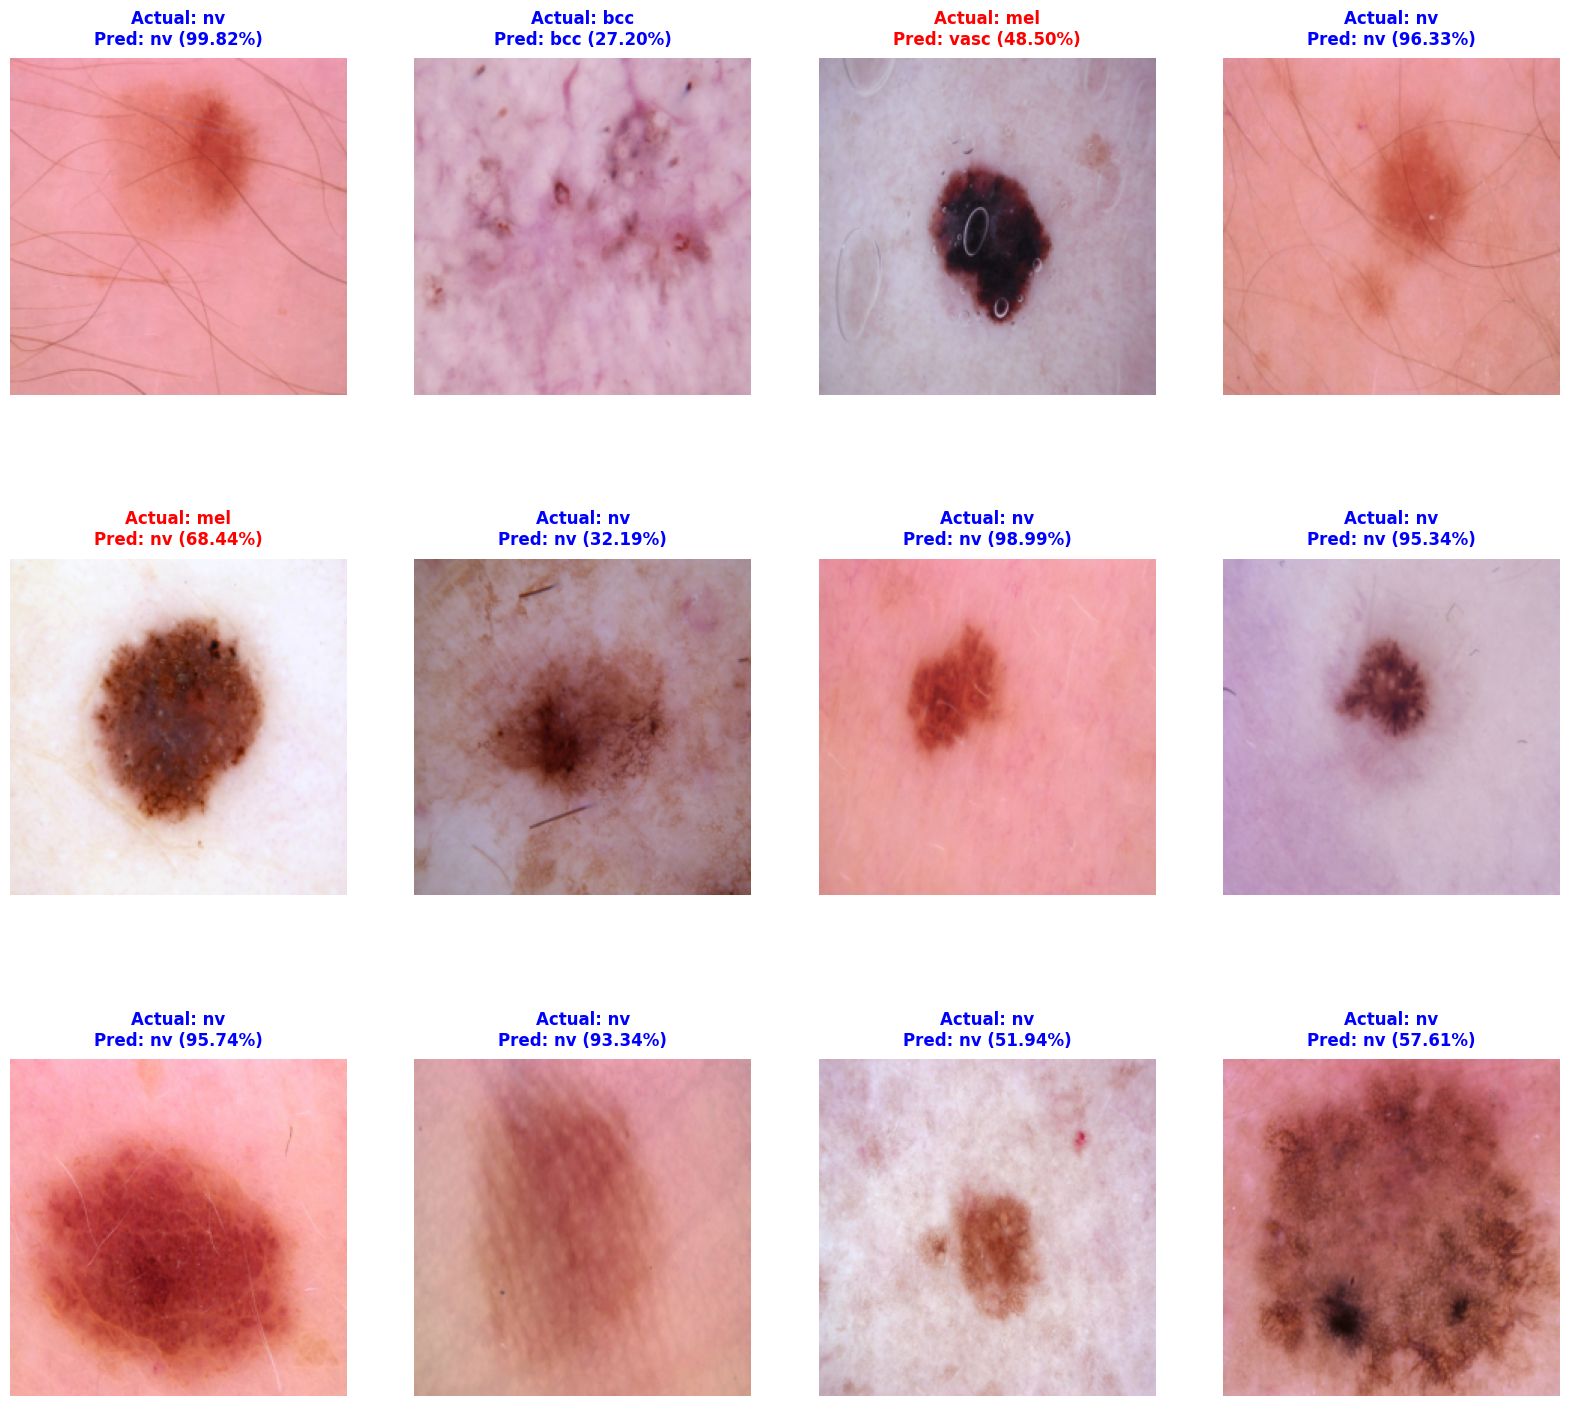


Generating Grad-CAM for Skin Lesions...
Generating XAI Brain Tumor Explanations...


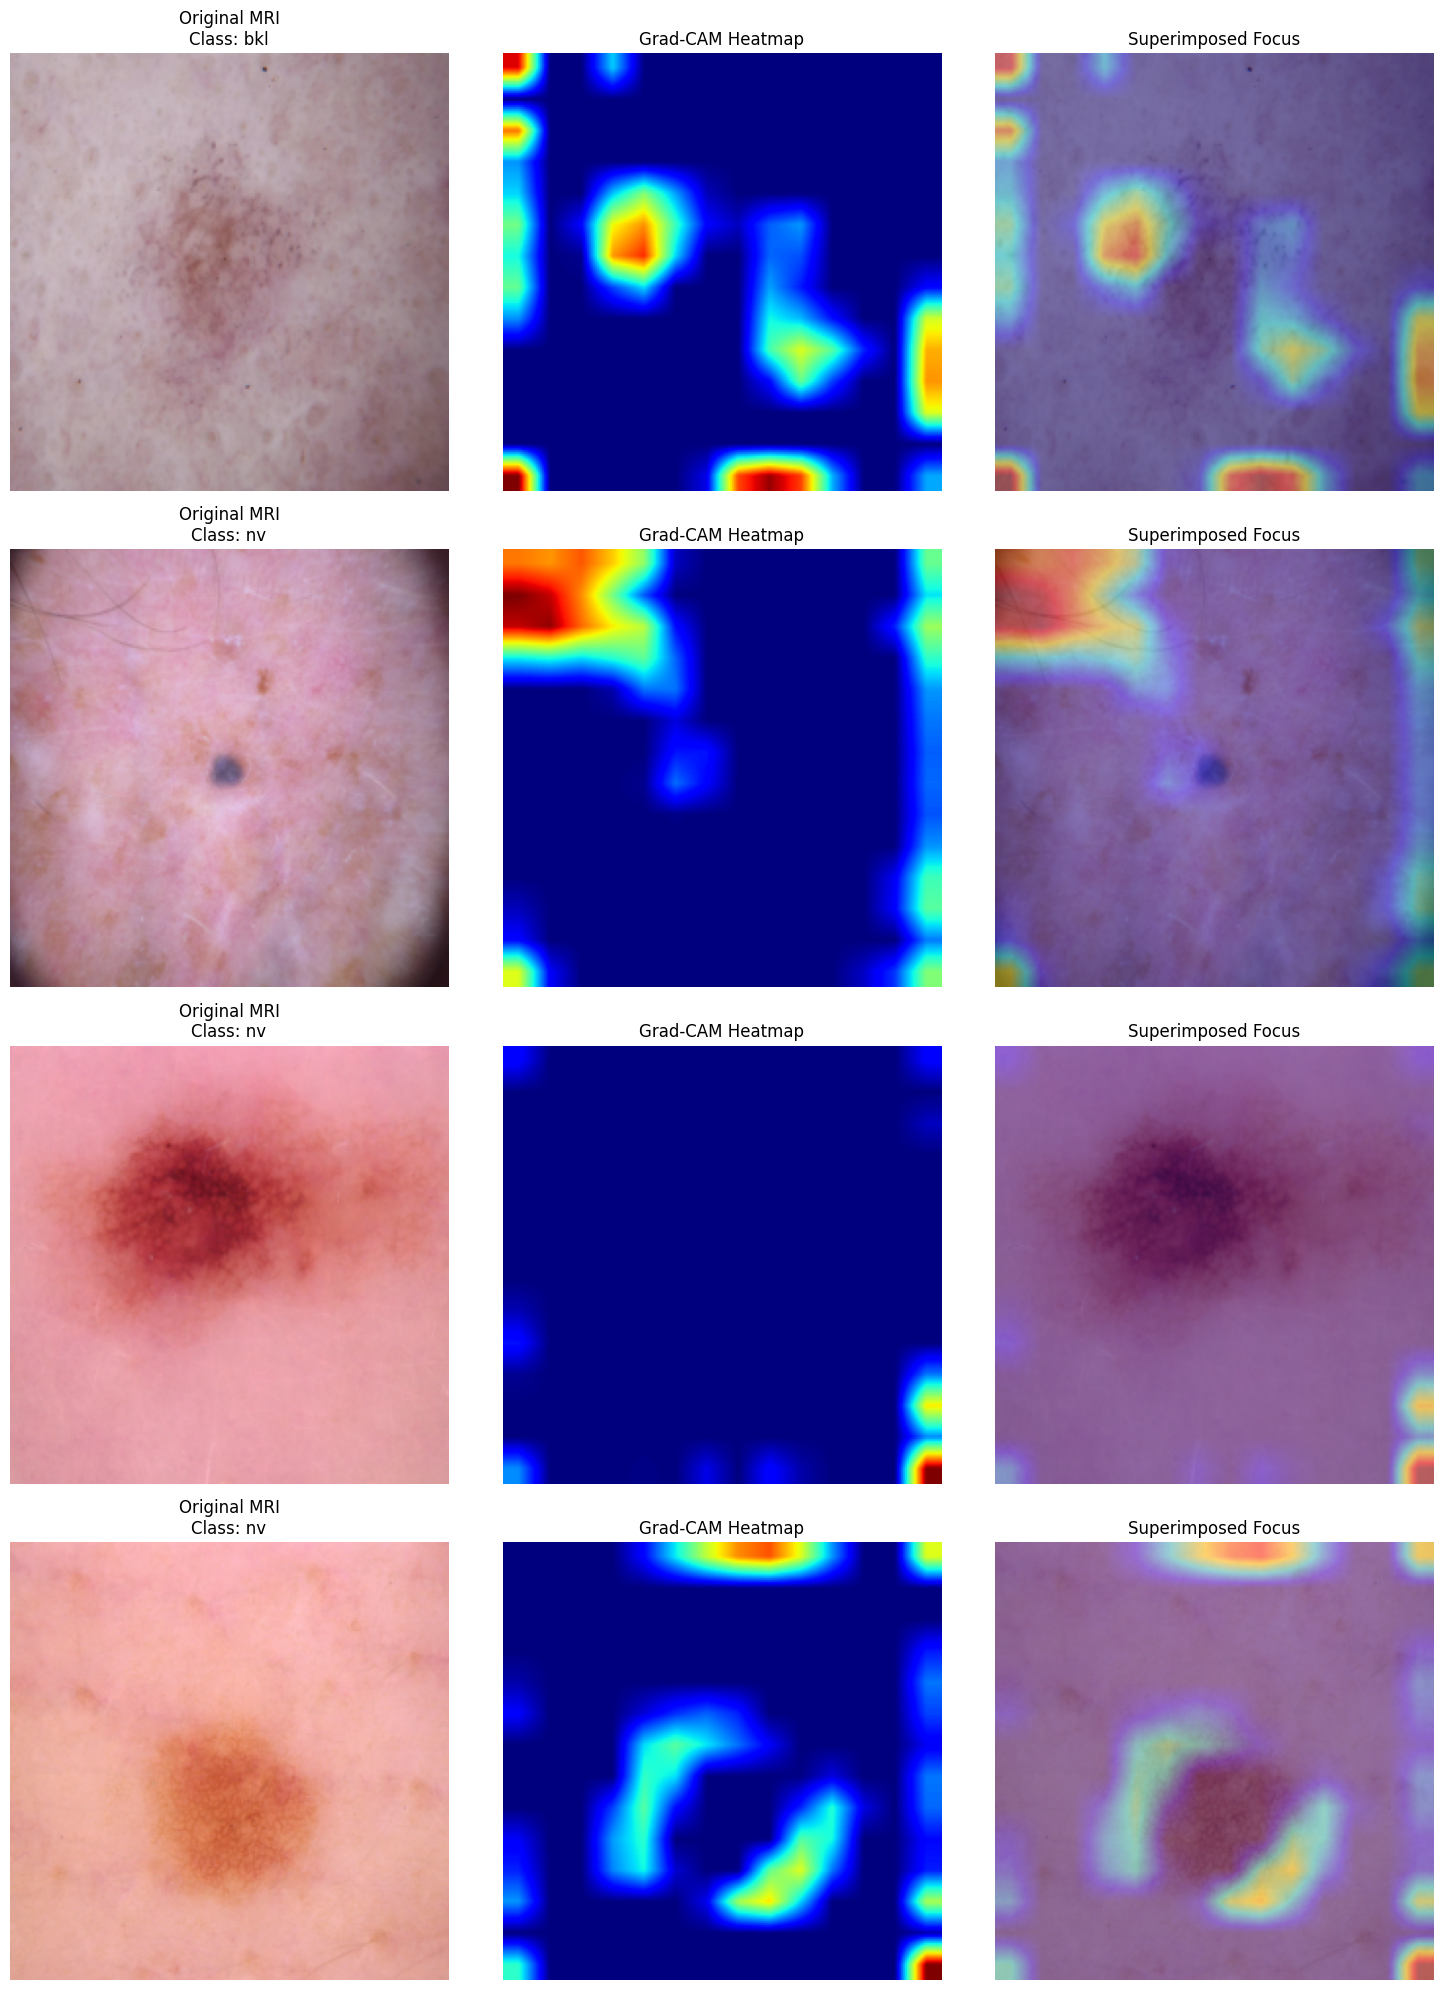

In [14]:
print("Visualizing Predictions...")
images_batch, labels_batch = next(iter(val_loader_skin))
images_batch = images_batch.to(device)
model_skin.eval()
with torch.no_grad():
    outputs_batch = model_skin(images_batch)

plot_multiclass_results_grid(
    images=images_batch.cpu(),
    labels=labels_batch.cpu(),
    outputs=outputs_batch.cpu(),
    label_names=list(label_map_skin.keys()),
    n_images=12,
    imgs_per_row=4
)

model_skin = fix_inplace_relu(model_skin)

print("\nGenerating Grad-CAM for Skin Lesions...")
plot_gradcam_multiclass(
    model_skin,
    val_ds_skin,
    device,
    list(label_map_skin.keys()),
    n_samples=4
)